# Figure: MET vs K
Hidemasa ISHII

In [1]:
using CSV, DataFrames, DataFramesMeta
using Statistics, Integrals, DifferentialEquations, DiffEqCallbacks
using CairoMakie
using Makie.GeometryBasics
import ColorSchemes as cs

In [2]:
# fixed parameters
r = 0.05
D = 0.005
ξ = 0.5

0.5

## load simulation results

In [3]:
# change directory if needed
let wd = "src"
    if splitdir(pwd())[end] != wd cd(wd) end
    # -> now, we are inside "src" directory!
end

In [4]:
# helper methods
df2met(df) = mean.(eachrow(select(df, Not(:K))))
df2se(df) = std.(eachrow(select(df, Not(:K)))) ./ sqrt(size(df, 2) - 1)

function get_met()
    # N values for panels 1 & 2
    N1 = [8, 64, 256, 1024]
    N2 = [8, 64, 256]
    # K values for panels 1 & 2
    K1 = collect(logrange(1e-2, 10, 13))
    K2 = collect(logrange(1, 10^4, 9))
    # record # samples for each N
    numsamples = Vector{Int64}()

    # MET for panel 1
    met1 = DataFrame(K=K1)
    se1 = DataFrame(K=K1)
    for N in N1
        if N == 16
            df1 = CSV.read("data/251120-080419_aet_n$N.csv", DataFrame)
            df2 = CSV.read("data/251120-083901_aet_n$N.csv", DataFrame)
        elseif N == 8
            df1 = CSV.read("data/251120-094419_aet_n$N.csv", DataFrame)
            df2 = CSV.read("data/251120-102236_aet_n$N.csv", DataFrame)
        else
            df1 = CSV.read("data/250822-092053_aet_n$N.csv", DataFrame)
            df2 = CSV.read("data/250825-082037_aet_n$N.csv", DataFrame)
        end
        df = innerjoin(df1, df2, on = :K)
        @assert all(met1.K .== df.K) "K valeus do not match: N=$N"
        met1[!, Symbol("N$N")] = df2met(df)
        se1[!, Symbol("N$N")] = df2se(df)
        push!(numsamples, size(df, 2) - 1)  # exclude K column
    end

    # MET for panel 2
    met2 = DataFrame(K=K2)
    se2 = DataFrame(K=K2)
    K12 = [K for K in K1 if K ∈ K2]  # overlap of K values
    for N in N2
        if N == 128
            df1 = CSV.read("data/250823-130332_aet_n$N.csv", DataFrame)
            df2 = CSV.read("data/250824-205122_aet_n$N.csv", DataFrame)
            df = innerjoin(df1, df2, on=:K)
            @assert all(met2.K .== df.K) "K valeus do not match: N=$N"
            met2[!, Symbol("N$N")] = df2met(df)
            se2[!, Symbol("N$N")] = df2se(df)
        elseif N in [8, 16, 64, 256]
            metdict = Dict()
            sedict = Dict()
            for K in K12
                metdict[K] = (@chain met1 begin
                    @select :K $(Symbol("N$N"))
                    @rsubset :K == K
                end)[1, Symbol("N$N")]
                sedict[K] = (@chain se1 begin
                    @select :K $(Symbol("N$N"))
                    @rsubset :K == K
                end)[1, Symbol("N$N")]
            end
            if N == 16
                df1 = CSV.read("data/251120-080729_aet_n$N.csv", DataFrame)
                df2 = CSV.read("data/251120-084141_aet_n$N.csv", DataFrame)
            elseif N == 8
                df1 = CSV.read("data/251120-094615_aet_n$N.csv", DataFrame)
                df2 = CSV.read("data/251120-102454_aet_n$N.csv", DataFrame)
            else
                df1 = CSV.read("data/250822-113506_aet_n$N.csv", DataFrame)
                df2 = CSV.read("data/250823-172105_aet_n$N.csv", DataFrame)
            end
            df = innerjoin(df1, df2, on=:K)
            for (K, metval, seval) in zip(df.K, df2met(df), df2se(df))
                metdict[K] = metval
                sedict[K] = seval
            end
            met2[!, Symbol("N$N")] = [metdict[K] for K in K2]
            se2[!, Symbol("N$N")] = [sedict[K] for K in K2]
        end
        push!(numsamples, size(df, 2) - 1)  # exclude K column
    end
    unique!(numsamples)
    @assert length(numsamples) == 1 "Different number of samples across N!"
    return (; N1, N2, met1, met2, se1, se2, numsample=only(numsamples))
end

get_met (generic function with 1 method)

In [5]:
# load dataset
data = get_met()
Nall = sort(unique([data.N1; data.N2]))

4-element Vector{Int64}:
    8
   64
  256
 1024

## generate the main figure

### plot MET

In [6]:
# new format for axes tick labels on log10 scale
const SUPERSCRIPT_DIGITS = collect("⁰¹²³⁴⁵⁶⁷⁸⁹")
const SUBSCRIPT_DIGITS   = collect("₀₁₂₃₄₅₆₇₈₉")

10-element Vector{Char}:
 '₀': Unicode U+2080 (category No: Number, other)
 '₁': Unicode U+2081 (category No: Number, other)
 '₂': Unicode U+2082 (category No: Number, other)
 '₃': Unicode U+2083 (category No: Number, other)
 '₄': Unicode U+2084 (category No: Number, other)
 '₅': Unicode U+2085 (category No: Number, other)
 '₆': Unicode U+2086 (category No: Number, other)
 '₇': Unicode U+2087 (category No: Number, other)
 '₈': Unicode U+2088 (category No: Number, other)
 '₉': Unicode U+2089 (category No: Number, other)

In [7]:
function superscript(n::Integer)
    if_pos = n >= 0
    if if_pos
        return join(SUPERSCRIPT_DIGITS[begin .+ reverse(digits(n))])
    else
        return "⁻" * join(SUPERSCRIPT_DIGITS[begin .+ reverse(digits(-n))])
    end
end

function log10format(value; digits=3, minabsexp=3)
    exponent = floor(Integer, log10(value))

    if abs(exponent) < minabsexp
        # no formatting for small value
        return "$(round(value, digits=max(1 - exponent, 1)))" 
    end

    coeff = round(value / 10.0^exponent, RoundNearestTiesUp; digits=digits)
    if coeff == 1
        return "10$(superscript(exponent))"
    else
        return "$(coeff)×10$(superscript(exponent))"
    end
end

log10format (generic function with 1 method)

In [8]:
function get_N_opts(N1, N2; palette=cs.tab10, 
    markers=[:circle, :utriangle, :rtriangle, :rect, :diamond]
)
    allN = sort(unique([N1; N2]))
    return (
        #dcol = Dict([N => palette[j] for (j, N) in enumerate(allN)]),
        dcol = Dict([N => :black for (j, N) in enumerate(allN)]),
        #dmarker = Dict([N => markers[j] for (j, N) in enumerate(allN)]),
        dmarker = Dict(8 => :circle, 16 => :utriangle, 64 => :rect, 128 => :rtriangle, 256 => :diamond, 1024 => :dtriangle)
    )
end

function getlog10lims(mnval, mxval, lowmargin, highmargin=lowmargin)
    mn, mx = log10.([mnval, mxval])
    return (
        low = 10^(mn - lowmargin * (mx - mn)),
        high = 10^(mx + highmargin * (mx - mn))
    )
end

function get_met_axes(data; figsize=(800, 400), r=r, D=D, ξ=ξ)
    (; N1, N2, met1, met2, se1, se2, numsample) = data  # expand arguments
    # generate Figure
    fig = Figure(size=figsize, figure_padding=5)

    # generate Axes
    axopts = (; 
        xscale=log10, xlabel="coupling strength K", xgridvisible=false,
        xtickformat=values -> log10format.(values, digits=2),
        xminorticksvisible=true, xminorticks=IntervalsBetween(10), 
        yscale=log10, ygridvisible=false,
        ytickformat=values -> log10format.(values, digits=2),
        yminorticksvisible=true, yminorticks=IntervalsBetween(10),
        yticks=(10.0).^(-5:5),
    )
    ax1 = Axis(fig[1, 1]; ylabel="mean escape time", axopts...)
    ax2 = Axis(fig[1, 2]; yaxisposition=:right, axopts...)
    linkyaxes!(ax1, ax2)  # yaxes synchronize: limits are dynamic (cannot be fixed)

    # fix x limits
    xlims!(ax1; getlog10lims(met1.K[begin], met1.K[end], 0.05, 0.03)...)
    xlims!(ax2; getlog10lims(met2.K[begin], met2.K[end], 0.08, 0.05)...)

    # fix y limits
    mnmet = minimum(
        [minimum(minimum.(eachcol(select(met, Not(:K))))) for met in (met1, met2)]
    )
    mxmet = maximum(
        [maximum(maximum.(eachcol(select(met, Not(:K))))) for met in (met1, met2)]
    )
    lowmargin, highmargin = (0.05, 0.12)
    ylims!(ax1, 10, getlog10lims(mnmet, mxmet, lowmargin, highmargin).high)
    ylims!(ax2, 10, getlog10lims(mnmet, mxmet, lowmargin, highmargin).high)

    # get the current axes limits (value of Observable object)
    xl1, xh1 = ax1.xaxis.attributes.limits[]
    xl2, xh2 = ax2.xaxis.attributes.limits[]
    yl, yh = ax1.yaxis.attributes.limits[]  # y axes are synchronized

    # show largest bifurcation point Kb
    Kb = r * (1 - r)
    vlines!(ax1, Kb, linewidth=1.5, linestyle=(:dashdotdot, :dense), color=:black)
    text!(ax1, Kb, yh; 
        text=rich("K", subscript("b"), "=$Kb"),
        align=(:left, :top), offset=(3, -3),
    )

    # plot options
    (; dcol, dmarker) = get_N_opts(N1, N2)  # Dict of colors
    opts = Dict(:color => (:black, 0), :strokewidth => 1, :markersize => 14)

    # make scatter plots
    delem = Dict()
    vec_frontelem = []
    for (ax, Nvec, met, se) in zip((ax1, ax2), (N1, N2), (met1, met2), (se1, se2))
        for N in Nvec
            lbl = "N=$N"
            s = scatter!(ax, met.K, met[!, Symbol("N$N")];
                strokecolor=(dcol[N], 0.8), marker=dmarker[N], label=lbl,
                opts...
            )
            errorbars!(ax, 
                met.K, met[!, Symbol("N$N")], se[!, Symbol("N$N")],
                linewidth=1, whiskerwidth=5, color=:black,
            )
            delem[lbl] = s
            push!(vec_frontelem, s)
        end
    end


    # panel labels
    lblopts = (; space=:relative, font=:bold, fontsize=24)
    t1 = text!(ax1, 0, 1; text="a", align=(:left, :top), offset=(5, 0), 
        #offset=(15, -20), 
        lblopts...
    )
    t2 = text!(ax2, 1, 0; text="b", align=(:right, :bottom), offset=(-5, 0), 
        #offset=(-15, 20), 
        lblopts...
    )
    vec_frontelem = [vec_frontelem; [t1, t2]]

    # adjust z-order: put scatter plots and panel labels in front
    for s in vec_frontelem
        translate!(s, 0, 0, 20)
    end

    # adjust layout
    colsize!(fig.layout, 1, Auto(size(met1, 1) / size(met2, 1)))
    colgap!(fig.layout, 1, 10)
    
    # return
    return (; fig=fig, axes=(ax1, ax2), dcol=dcol, delem=delem)
end

get_met_axes (generic function with 1 method)

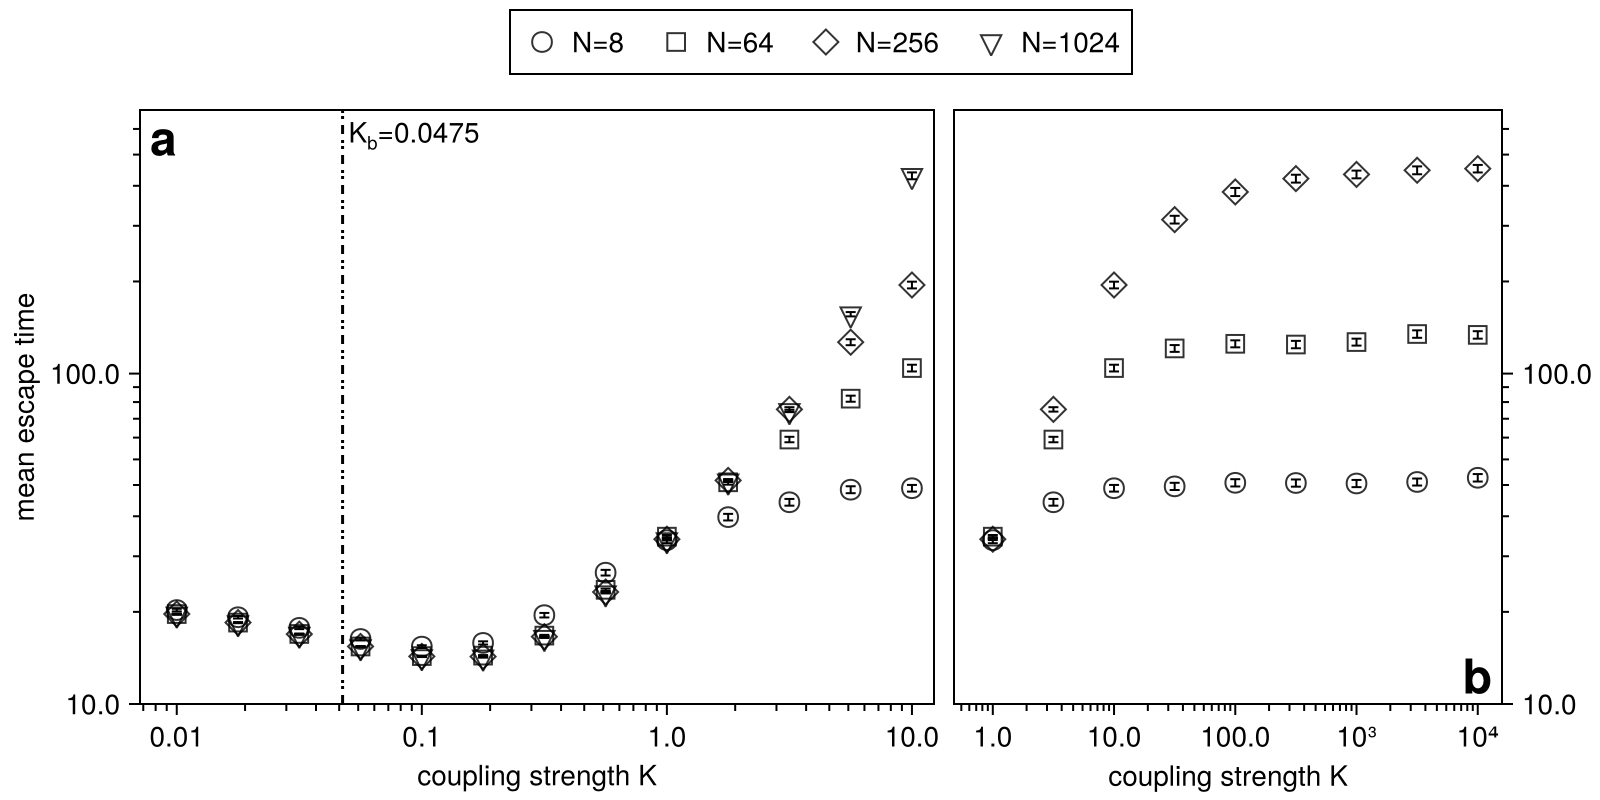

In [9]:
let ifsave = false
    (; fig, axes, delem) = get_met_axes(data)
    lbl = ["N=$N" for N in Nall]
    Legend(fig[0, 1:2], [delem[l] for l in lbl], lbl, orientation=:horizontal)
    display(fig)
    if ifsave save("output/met-only.pdf", fig) end
end;

### Limiting values predicted by the mean first passage time formula

In [10]:
"""calculate mean first passage time"""
function outer_integrand(u_tmp, y, p)
    (; V::Function, D::Real) = p  # expand parameters
    u_tmp[begin] = calc_inner_integral(only(y), V, D)
end

function inner_integrand(v_tmp, z, p)
    (; V::Function, D::Real, y::Real) = p  # expand parameters
    v_tmp[begin] = exp((V(y) - V(only(z))) / D)  # implementation here needs caution
end

function calc_inner_integral(y::Real, V::Function, D)
    prototype = zeros(1)
    domain = ([-Inf], [y])  # (lb, ub)
    p = (V=V, D=D, y=y)
    prob = IntegralProblem(IntegralFunction(inner_integrand, prototype), domain, p)
    sol = solve(prob, QuadGKJL(), reltol=1e-9,
        # abstol must be very small in cases of large N (i.e. small diff. coef. D / N)
        abstol=1e-44,
    )
    return only(sol.u)
end

function calc_mfpt(V::Function, D, ξ; lb=0.0)
    prototype = [10.0]
    domain = ([lb], [ξ])  # (lb, ub)
    p = (V=V, D=D)
    prob = IntegralProblem(IntegralFunction(outer_integrand, prototype), domain, p)
    sol = solve(prob, QuadGKJL(), abstol=1e-10, reltol=1e-8)
    return only(sol.u) / D
end

calc_mfpt (generic function with 1 method)

In [11]:
"""potential of the isolated dynamics"""
function V_iso(x, r=r)
    return x^4 / 4 - (1 + r) / 3 * x^3 + r / 2 * x^2
end

V_iso

In [12]:
# limiting cases
T0 = calc_mfpt(V_iso, D, ξ)
dT∞ = Dict([N => calc_mfpt(V_iso, D / N, ξ) for N in data.N2])

Dict{Int64, Float64} with 3 entries:
  64  => 129.829
  8   => 47.2689
  256 => 406.782

In [13]:
function add_mfpt!(axes, dcol;
    T0=T0, dT∞=dT∞, N1=data.N1, N2=data.N2
)
    ax1, ax2 = axes
    ### T0 ###
    T0_opt = (color = :black, linewidth = 2, linestyle = (:dash, :loose))
    hlines!(ax1, T0; T0_opt...)
    text!(ax1, 0.01, T0, 
        text=rich("T", subscript("0"), "≈$(round(T0, digits=2))"), 
        align=(:left, :bottom), offset=(0, 2)
    )
    hlines!(ax2, T0; T0_opt...)
    text!(ax2, 10^(3.0), T0, 
        text=rich("T", subscript("0"), "≈$(round(T0, digits=2))"), 
        align=(:right, :top), offset=(0, -2)
    )
    ### T∞ ###
    T∞_opt = (; linestyle = (:dot, :dense))
    t_lw = 1.0 .+ collect(0:length(N2) - 1) * 0.5  #(1.5, 2, 2.5, 3.0)
    for (N, lw) in zip(N2, t_lw)
        hlines!(ax2, dT∞[N]; color=dcol[N], linewidth=lw, T∞_opt...)
        text!(ax2, 0.5, dT∞[N],
            text=rich("T", subscript("∞"), "($N)"), 
            color=dcol[N],
            align=(:left, :bottom), offset=(1, 1)
        )
    end
    
    return nothing
end

add_mfpt! (generic function with 1 method)

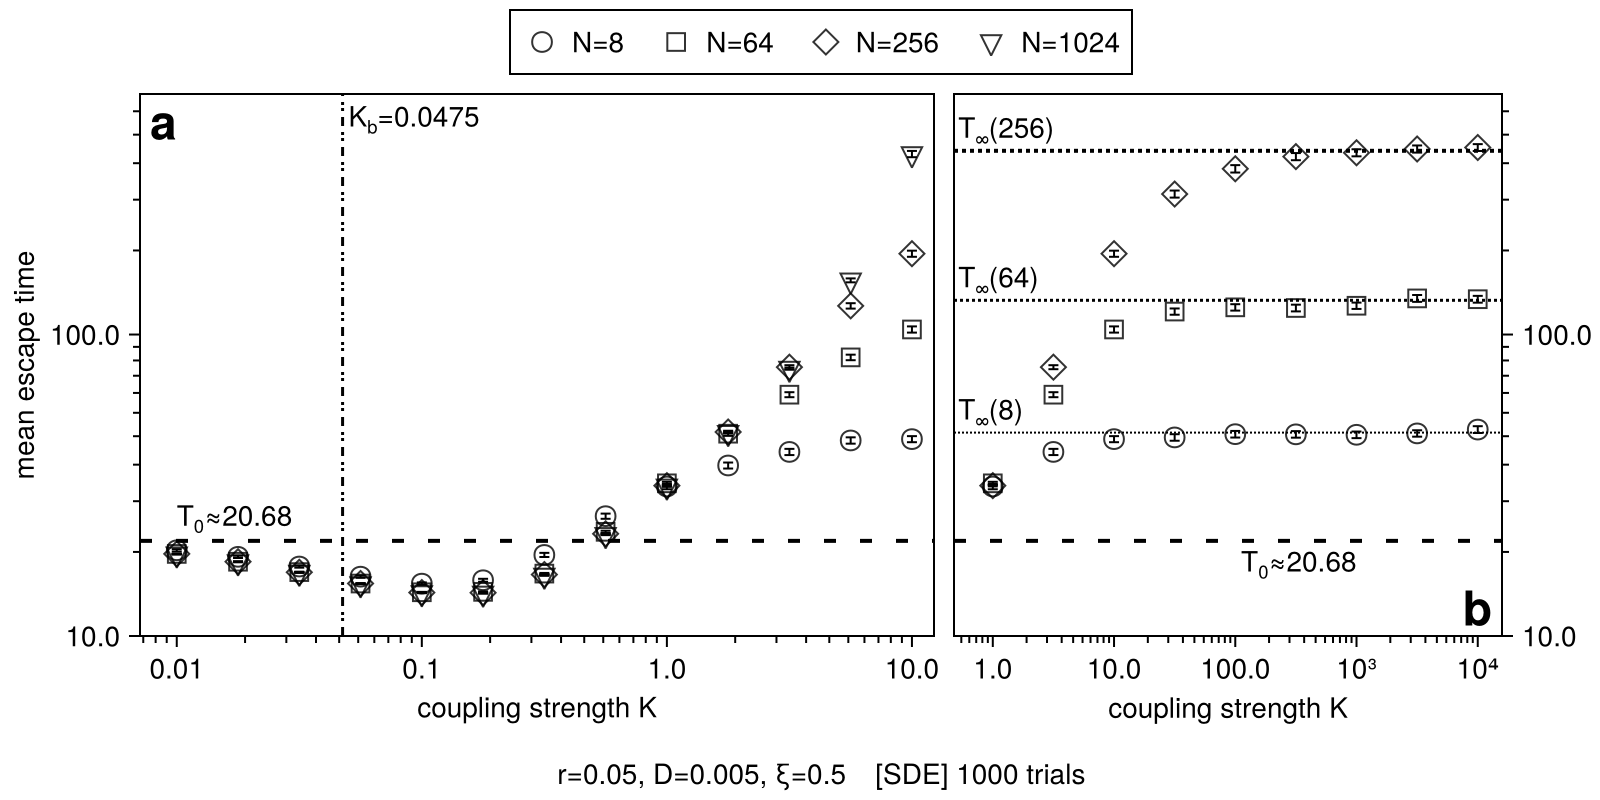

In [14]:
let ifsave = false
    # generate Figure and Axes
    (; fig, axes, dcol, delem) = get_met_axes(data)
    # annotate MFPT
    add_mfpt!(axes, dcol)
    # add Legend
    lbl = ["N=$N" for N in Nall]
    Legend(fig[0, 1:2], [delem[l] for l in lbl], lbl, orientation=:horizontal)
    # annotate parameter values
    Label(fig[2, 1:2],
        "r=$r, D=$D, ξ=$ξ \t [SDE] $(data.numsample) trials",
        tellwidth=false
    )
    # adjust layout
    rowgap!(fig.layout, 1, 10)
    # display figure
    display(fig)
    if ifsave save("output/met-mfpt.pdf", fig) end
end;

### three phases

$$K_1 = (1 - r + r^2) / 3$$
* $(1 - r) / 4$ is another candidate of $K_1$, where $f_X(x; X=0)$ turns monostable.
$$K_2 \approx 7.99473$$

In [15]:
function add_Kc!(axes; K1=(1 - r + r^2) / 3, K2=7.99473,
    c1=cs.Accent_3[1], c2=cs.Accent_3[2], c3=cs.Accent_3[3],
    polyalpha=0.2
)
    ax1, ax2 = axes
    # get the current axes limits (value of Observable object)
    xl1, xh1 = ax1.xaxis.attributes.limits[]
    xl2, xh2 = ax2.xaxis.attributes.limits[]
    yl, yh = ax1.yaxis.attributes.limits[]  # y axes are synchronized
    ### vertical lines of K1 and K2 ###
    vlopts = (color=:black, linestyle=(:dash, :dense), linewidth=1.5)
    vlines!(ax1, K1; vlopts...)
    text!(ax1, K1, yh; text="K₁=$(round(K1, digits=6))", align=(:left, :top), offset=(3, -3))
    for ax in axes
        vlines!(ax, K2; vlopts...)
        text!(ax, K2, yl; text="K₂≈$(round(K2, digits=2))", 
            align=(:right, :bottom), offset=(-2, 3)
        )
    end
    ### fill the background ###
    # draw polygon
    # - when one of the quantities is smaller than 1, use relative spacing
    lK1, lK2, lxl1, lxh1, lxl2, lxh2 = log10.([K1, K2, xl1, xh1, xl2, xh2])
    w1 = lxh1 - lxl1
    w2 = lxh2 - lxl2
    # panel 1
    ax1p1 = poly!(ax1,
        Rect(0, 0, (lK1 - lxl1) / w1, 1),
        space=:relative,
        color=c1, alpha=polyalpha,
    )
    ax1p2 = poly!(ax1,
        Rect((lK1 - lxl1) / w1, 0, (lK2 - lK1) / w1, 1),
        space=:relative,
        color=c2, alpha=polyalpha,
    )
    ax1p3 = poly!(ax1,
        Rect(K2, yl, xh1 - K2, yh - yl),
        color=c3, alpha=polyalpha,
    )
    # panel 2
    ax2p2 = poly!(ax2,
        Rect((lK1 - lxl2) / w2, 0, (lK2 - lK1) / w2, 1),
        space=:relative,
        color=c2, alpha=polyalpha,
    )
    ax2p3 = poly!(ax2,
        Rect(K2, yl, xh2 - K2, yh - yl),
        color=c3, alpha=polyalpha,
    )
    # adjust z-order
    translate!(ax1p1, 0, 0, 1)
    translate!(ax1p2, 0, 0, 1)
    translate!(ax2p3, 0, 0, 1)
    translate!(ax2p2, 0, 0, 1)
    translate!(ax2p3, 0, 0, 1)
end

add_Kc! (generic function with 1 method)

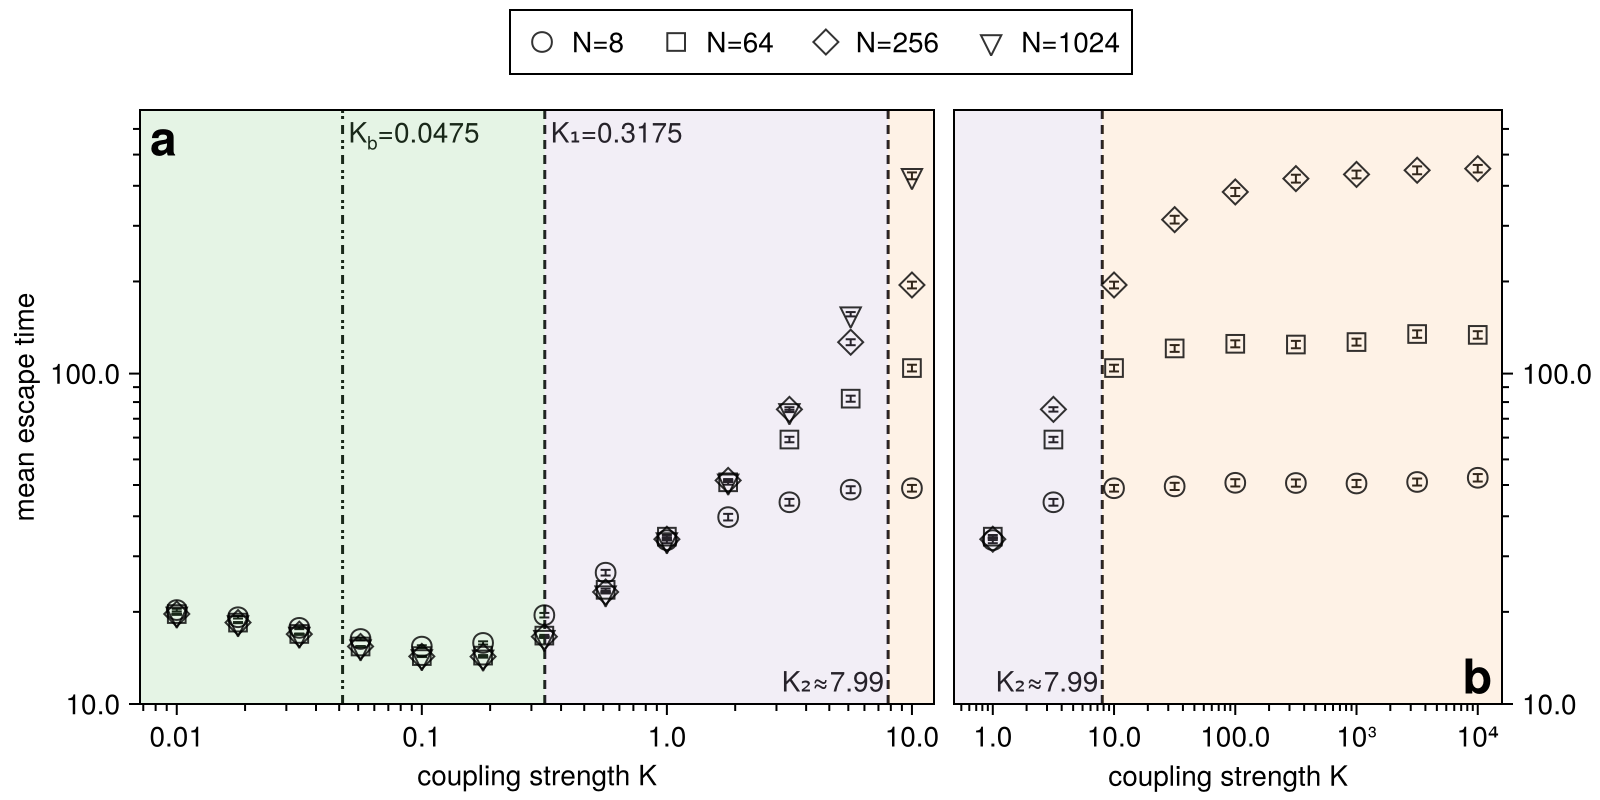

In [16]:
let 
    (; fig, axes, delem) = get_met_axes(data)
    add_Kc!(axes)
    lbl = ["N=$N" for N in Nall]
    Legend(fig[0, 1:2], [delem[l] for l in lbl], lbl, orientation=:horizontal)
    display(fig)
end;

### predictions using the mean first passage time formula

In [17]:
"""calculate mean first passage time"""
function outer_integrand(u_tmp, y, p)
    (; V::Function, D::Real) = p  # expand parameters
    u_tmp[begin] = calc_inner_integral(only(y), V, D)
end

function inner_integrand(v_tmp, z, p)
    (; V::Function, D::Real, y::Real) = p  # expand parameters
    v_tmp[begin] = exp((V(y) - V(only(z))) / D)  # implementation here needs caution
end

function calc_inner_integral(y::Real, V::Function, D)
    prototype = zeros(1)
    domain = ([-Inf], [y])  # (lb, ub)
    p = (V=V, D=D, y=y)
    prob = IntegralProblem(IntegralFunction(inner_integrand, prototype), domain, p)
    sol = solve(prob, QuadGKJL(), reltol=1e-9,
        # abstol must be very small in cases of large N (i.e. small diff. coef. D / N)
        abstol=1e-44,
    )
    return only(sol.u)
end

function calc_mfpt(V::Function, D, ξ; lb=0.0)
    prototype = [10.0]
    domain = ([lb], [ξ])  # (lb, ub)
    p = (V=V, D=D)
    prob = IntegralProblem(IntegralFunction(outer_integrand, prototype), domain, p)
    sol = solve(prob, QuadGKJL(), abstol=1e-10, reltol=1e-8)
    return only(sol.u) / D
end

calc_mfpt (generic function with 1 method)

In [18]:
### Stochastic Mean-Field Dynamics ###
#zstar(K, N, D=D) = D / K * (1 - 1 / N)  # more precise model incorporating correlations
zstar(K, N, D=D) = D / K  # rough model ignoring correlations (assuming large N)

function V_smfd(x, z, r=r)
    return x^4 / 4 - (1 + r) / 3 * x^3 + (r + 3z) / 2 * x^2 - (1 + r) * z * x
end

V_smfd (generic function with 2 methods)

In [19]:
# prediction of SMFD
K1smfd = collect(logrange(10^(-1), 10^(1.2), 11))
K2smfd = collect(logrange(10^(-0.3), 10^(4.2), 41))
T1smfd = Matrix{Float64}(undef, length(data.N1), length(K1smfd))
T2smfd = Matrix{Float64}(undef, length(data.N2), length(K2smfd))
for (Kvec, Tvec, Nvec) in zip((K1smfd, K2smfd), (T1smfd, T2smfd), (data.N1, data.N2))
    for (j, K) in enumerate(Kvec)
        for (n, N) in enumerate(Nvec)
            V_Θ(x) = V_smfd(x, zstar(K, N))
            Tvec[n, j] = calc_mfpt(V_Θ, D / N, ξ)
        end
    end
end

In [20]:
function add_smfd!(axes, dcol;
    K1smfd=K1smfd, K2smfd=K2smfd, T1smfd=T1smfd, T2smfd=T2smfd,
    N1=data.N1, N2=data.N2
)
    ax1, ax2 = axes
    ### SMFD ###
    delem = Dict()  # to export resultant objects
    # options
    smfdopts = (; color = cs.seaborn_bright[4], linestyle = (:dashdot, :dense))
    dlw = Dict(8 => 0.8, 16 => 1.0, 64 => 1.5, 128 => 2.0, 256 => 2.5, 1024 => 3.0)
    dalpha = Dict(8 => 1.0, 16 => 1.0, 64 => 1.0, 128 => 0.8, 256 => 0.6, 1024 => 0.4)
    for (ax, Kvec, Tvec, Nvec) in zip(
        axes, (K1smfd, K2smfd), (T1smfd, T2smfd), (N1, N2)
    )
        for (j, N) in enumerate(Nvec)
            lbl = "SMFD($N)"
            l = lines!(ax, Kvec, Tvec[j, :];
                linewidth=dlw[N], alpha=dalpha[N], label=lbl, smfdopts...
            )
            delem[lbl] = l
        end
    end
    return delem
end

add_smfd! (generic function with 1 method)

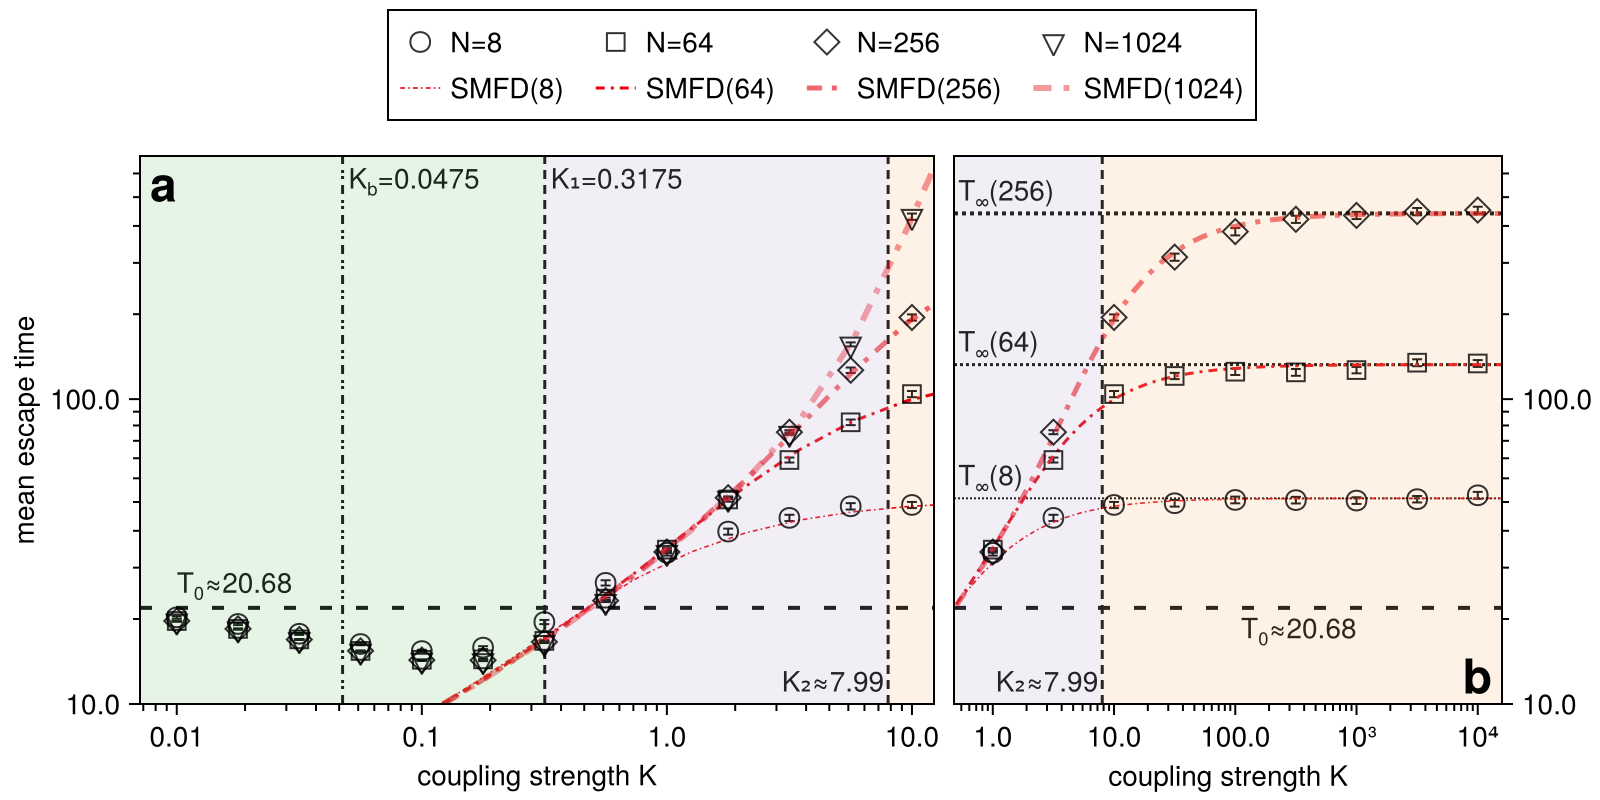

In [21]:
let 
    (; fig, axes, dcol, delem) = get_met_axes(data)
    add_mfpt!(axes, dcol)
    add_Kc!(axes)
    delem2 = add_smfd!(axes, dcol)
    delem = Dict(delem..., delem2...)
    lbl = [["N=$N" for N in Nall]; ["SMFD($N)" for N in Nall]]
    Legend(fig[0, 1:2], [delem[l] for l in lbl], lbl, 
        orientation=:vertical, nbanks=4,
        tellheight=true, tellwidth=false,
    )
    display(fig)
end;

### prediction of Deterministic Mean-Field Dynamics (DMFD)

In [22]:
zstar∞(K, D=D) = D / K

smfd_drift(X, K, r=r, D=D) = (
    -X^3 + (1 + r) * X^2 - (r + 3 * zstar∞(K, D)) * X + (1 + r) * zstar∞(K, D)
)

@views function travel_time(K; endpoint=ξ, M=10001)
    X = collect(range(0, endpoint, M))
    ΔX = X[begin+1:end] - X[begin:end-1]
    return sum(1 ./ smfd_drift.(X[begin:end-1], K) .* ΔX)
end

travel_time (generic function with 1 method)

In [23]:
# prediction of DMFD
Kdmfd = collect(logrange(0.1, 7.9, 101))
Tdmfd = [travel_time(K) for K in Kdmfd];

In [24]:
"""add prediction of DMFD to the axes"""
function add_dmfd!(axes; Kdmfd=Kdmfd, Tdmfd=Tdmfd)
    ax1, ax2 = axes
    dmfdopts = (
        color = (cs.seaborn_bright[1], 1.0), 
        linestyle = (:dot, :dense), 
        linewidth = 2
    )
    delem = Dict()
    for ax in axes
        lbl = "DMFD"
        l = lines!(ax, Kdmfd, Tdmfd; label=lbl, dmfdopts...)
        delem[lbl] = l
    end
    return delem
end

add_dmfd!

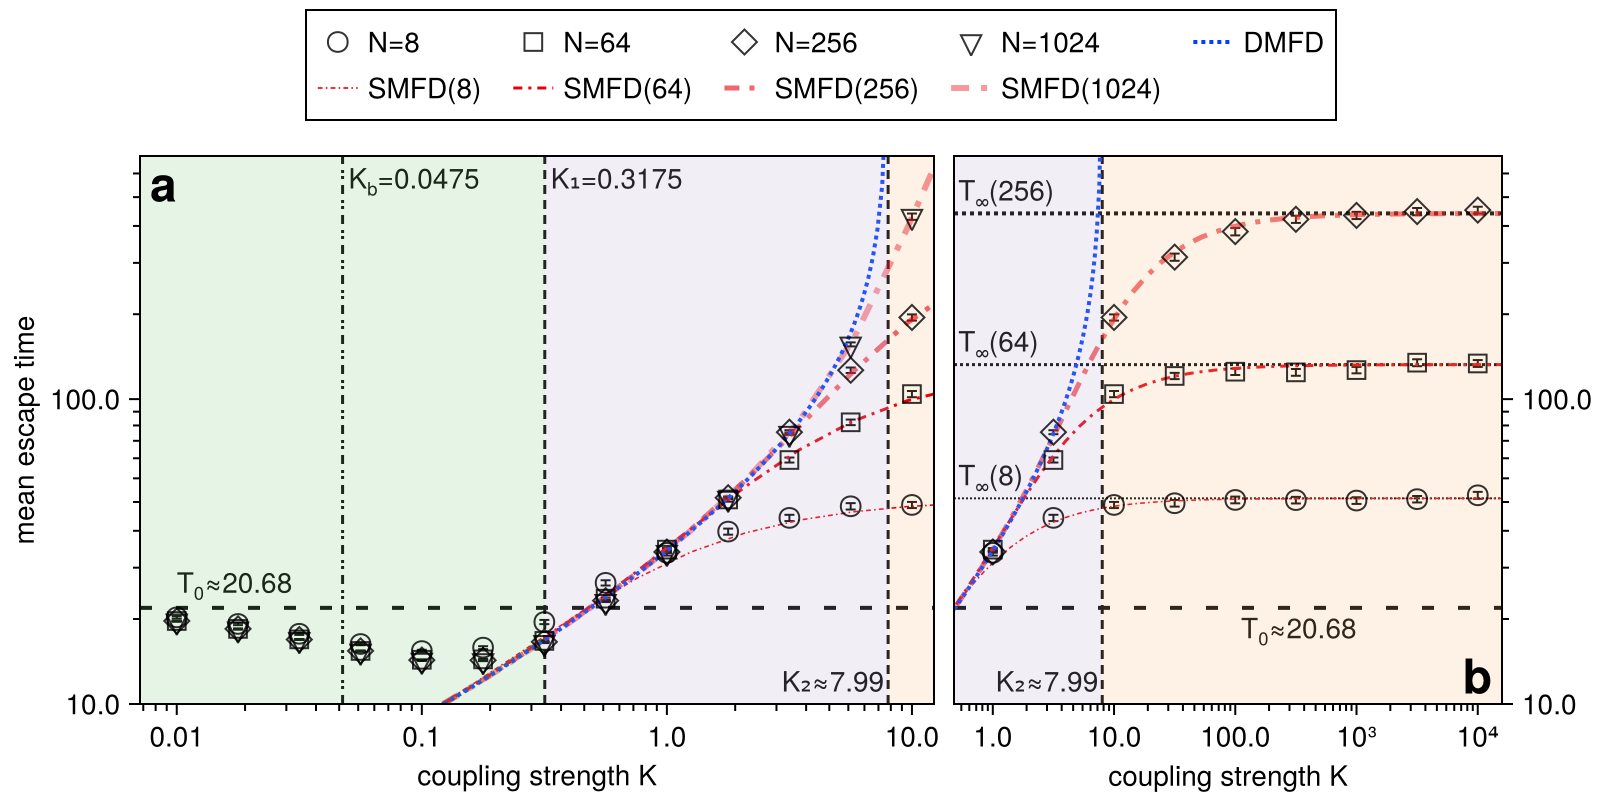

In [25]:
let 
    (; fig, axes, dcol, delem) = get_met_axes(data)
    add_mfpt!(axes, dcol)
    add_Kc!(axes)
    delem2 = add_smfd!(axes, dcol)
    delem3 = add_dmfd!(axes)
    # put Legend
    delem = Dict(delem..., delem2..., delem3...)
    lbl = [["N=$N" for N in Nall]; ["DMFD"]; ["SMFD($N)" for N in Nall]]
    Legend(fig[0, 1:2], [delem[l] for l in lbl], lbl, 
        nbanks=5, #orientation=:horizontal, valign=:top,
        tellheight=true, tellwidth=false,
    )
    display(fig)
end;

### prediction of Nonlinear Mean-Field Fokker-Planck Equation (NlinMFFPE)

In [26]:
### methods related to spatial discretization ###
"""generate an array of calculation points `x`"""
function get_x(a, b, Δx, ξ)
    #M = round(Int, (b - a) / Δx) + 1  # the number of data points
    x = [[a - Δx]; collect(a:Δx:b); [b + Δx]]  # extended x positions x0, x1, ..., x_{M+1}
    # warn if the choice of (a, b, Δx) is inappropriate
    if !(0 ∈ x) error("`x` does not contain `0` for a=$a, b=$b, Δx=$Δx") end
    if !(ξ ∈ x) error("`x` does not contain `ξ=$ξ` for a=$a, b=$b, Δx=$Δx") end
    if !(1 ∈ x) @warn "`x` does not contain `1`" a=a b=b Δx=Δx end
    return x
end

"""return the number of data points `M` from `x`"""
get_M(x) = length(x) - 2  # subtract the number of extended points

"""get the index of x = 0"""
idx_at0(x) = only(indexin(0, x))

"""get the index of x = ξ"""
idx_atξ(x, ξ) = only(indexin(ξ, x))

"""calculate the mean field X"""
@views calc_X(p, x, Δx) = sum(p[begin+1:end-1] .* x[begin+1:end-1]) * Δx

"""update p_0 and p_{M+1} to impose the no-flux boundary condition"""
@views function boundarycond!(p, param, X)
    (; K, D, Δx, x, f) = param  # expand parameters
    # p_0
    p[begin] = p[begin+2] - 2 * Δx / D * (
        f[begin] + K * (X - x[begin+1])
    ) * p[begin+1]
    # p_{M+1}
    p[end] = p[end-2] + 2 * Δx / D * (
        f[end] + K * (X - x[end-1])
    ) * p[end-1]
    return nothing
end

### define the system ###
bistable_flow(x, r) = -x * (x - r) * (x - 1)
dfdx(x, r) = -3 * x^2 + 2 * (1 + r) * x - r

@views function nlinmffpe!(dp, p, param, t)
    (; r, K, D, Δx, x, f, K_min_dfdx) = param  # expand parameters
    X = calc_X(p, x, Δx)  # mean field
    boundarycond!(p, param, X)  # impose boundary condition
    # update dot{p}_1, ..., dot{p}_M
    dp[begin+1:end-1] .= (
        K_min_dfdx .* p[begin+1:end-1]
        + (K * (x[begin+1:end-1] .- X) .- f) .* (
            (p[begin+2:end] .- p[begin:end-2]) / (2 * Δx)
        )
        + D * (p[begin+2:end] .+ p[begin:end-2] .- 2 * p[begin+1:end-1]) / (Δx^2)
    )
end

### helper methods to perform the numerical integration ###
"""generate a NamedTuple of parameters"""
@views function init_param(r, K, D, ξ, a, b, Δx, Jξmin)
    x = get_x(a, b, Δx, ξ)
    return init_param(r, K, D, ξ, Δx, Jξmin, x, 
        bistable_flow.(x[begin+1:end-1], r),  # f
        K .- dfdx.(x[begin+1:end-1], r),  # K_min_dfdx
    )
end

function init_param(r, K, D, ξ, Δx, Jξmin, x, f, K_min_dfdx)
    return (
        r=r, K=K, D=D, x=x, Δx=Δx, ξidx=idx_atξ(x, ξ), Jξmin=Jξmin, 
        f=f, K_min_dfdx=K_min_dfdx,
    )
end

"""initialize p(x) that has delta-peak at x=0"""
@views function init_p0(param)
    (; Δx, x) = param  # expand parameters
    init = zeros(length(x))
    init[idx_at0(x)] = 1 / Δx
    boundarycond!(init, param, calc_X(init, x, Δx))  # impose boundary condition
    return init
end

"""calculate the flux J_i"""
calc_Ji(p, param, i) = calc_Ji(p, param, i, calc_X(p, param.x, param.Δx))

calc_Ji(p, param, i, X) = (
    (param.f[i] + param.K * (X - param.x[begin+i])) * p[begin+i]
    - param.D * (p[begin+i+1] - p[begin+i-1]) / (2 * param.Δx)
)

"""return true if termination condition `X > 0.9 && Jξ < Jξmin` is satisfied"""
function terminate_cond(u, t, int)
    X = calc_X(u, int.p.x, int.p.Δx)
    return X > 0.9 && calc_Ji(u, int.p, int.p.ξidx, X) < int.p.Jξmin
end

# callback to terminate the simulation
terminate_cb = DiscreteCallback(
    terminate_cond, integrator -> terminate!(integrator); 
    save_positions=(true, false)  # only save the data just before termination
)

"""calculate X and Jξ upon saving"""
function savefunc_Jξ_X(u, t, int)
    X = calc_X(u, int.p.x, int.p.Δx)
    return (X, calc_Ji(u, int.p, int.p.ξidx, X))
end

"""main method"""
function solve_X_Jξ(param; terminate_cb=terminate_cb, kwargs...)
    p0 = init_p0(param)
    # set up SaveingCallback to save X and Jξ
    saved_values = SavedValues(Float64, Tuple{Float64, Float64})  # results 
    saving_cb = SavingCallback(savefunc_Jξ_X, saved_values, saveat=get(kwargs, :saveat, 0.1))
    # pack the Callbacks
    cbset = CallbackSet(saving_cb, terminate_cb)
    # numerical integration
    prob = ODEProblem(nlinmffpe!, p0, get(kwargs, :tspan, 1e4), param)
    sol = solve(prob, Tsit5(), abstol=1e-6, reltol=1e-3, save_everystep=false,
        callback=cbset, maxiters=5e6
    )
    if sol.retcode != ReturnCode.T(2)
        @warn "numerical integration was not terminated" retcode=sol.retcode
    end
    return (t=saved_values.t, u=hcat(collect.(saved_values.saveval)...))
end

"""calculate MET from a solution of NlinMFFPE"""
sol2met(sol, Δt) = @views sum(sol.t .* sol.u[2, :]) * Δt  # faster with view

sol2met

In [27]:
function gen_csv_FPE(; r=r, D=D, ξ=ξ, 
    a=-0.5, b=1.3, Δx=1e-3, Jξmin=1e-4, Δt=0.1
)
    # generate K values
    K_FPE = collect(logrange(10^(-2.2), 10^(0.8), 21))
    #K_FPE = collect(logrange(10^(-2.25), 10^(-0.5), 7))

    # preparation
    x = get_x(a, b, Δx, ξ)
    f = bistable_flow.(@view(x[begin+1:end-1]), r)
    vec_dfdx = dfdx.(@view(x[begin+1:end-1]), r)

    # calculate MET
    T_FPE = Vector{Float64}(undef, length(K_FPE))
    for (i, K) in enumerate(K_FPE)
        println("K=$K ($i / $(length(K_FPE)))")
        param = init_param(
            r, K, D, ξ, Δx, Jξmin, x, f, K .- vec_dfdx
        )
        sol = solve_X_Jξ(param; saveat=Δt)
        T_FPE[i] = sol2met(sol, Δt)
    end
    #return "STOPPED FOR DEBUGGING"
    # export results and parameters
    CSV.write("output/250823-fpe-res.csv", DataFrame(K=K_FPE, T_FPE=T_FPE))
    CSV.write("output/250823-fpe-param.csv", DataFrame(
        a=[a], b=[b], Δx=[Δx], Jξmin=[Jξmin], Δt=[Δt]
    ))
    return nothing
end

gen_csv_FPE (generic function with 1 method)

In [28]:
# get predictions if needed
if_calc_FPE = false

if if_calc_FPE
    gen_csv_FPE()
end

In [29]:
function load_FPE_df()
    dfparam = CSV.read("output/250823-fpe-param.csv", DataFrame)
    dfres = CSV.read("output/250823-fpe-res.csv", DataFrame)
    return (
        fpe_param=(
            a=only(dfparam.a), 
            b=only(dfparam.b), 
            Δx=only(dfparam.Δx),
            Jξmin=only(dfparam.Jξmin),
            Δt=only(dfparam.Δt)
        ),
        K_FPE=dfres.K,
        T_FPE=dfres.T_FPE,
    )
end

load_FPE_df (generic function with 1 method)

In [30]:
(; fpe_param, K_FPE, T_FPE) = load_FPE_df();

In [31]:
"""add prediction of NlinMFFPE to the axes"""
function add_fpe!(axes, fig; fpe_param=fpe_param, K_FPE=K_FPE, T_FPE=T_FPE)
    (; a, b, Δx, Jξmin, Δt) = fpe_param
    ax1, ax2 = axes
    fpeopts = (
        color = (cs.seaborn_dark[3], 0.8),
        linestyle = (:dash, :dense), 
        linewidth = 4
    )
    delem = Dict()
    lbl = "NlinMFFPE"
    l = lines!(ax1, K_FPE, T_FPE; label=lbl, fpeopts...)
    l = lines!(ax2, K_FPE, T_FPE; label=lbl, fpeopts...)
    delem[lbl] = l
    if false
        Label(fig[2, 1], rich(
            "[NlinMFFPE] (a, b)=($a, $b), Δx=$Δx, J",
            subscript("ξ,min"),
            "=$Jξmin, Δt=$Δt"
        ), tellwidth=false)
    end
    return delem
end

add_fpe!

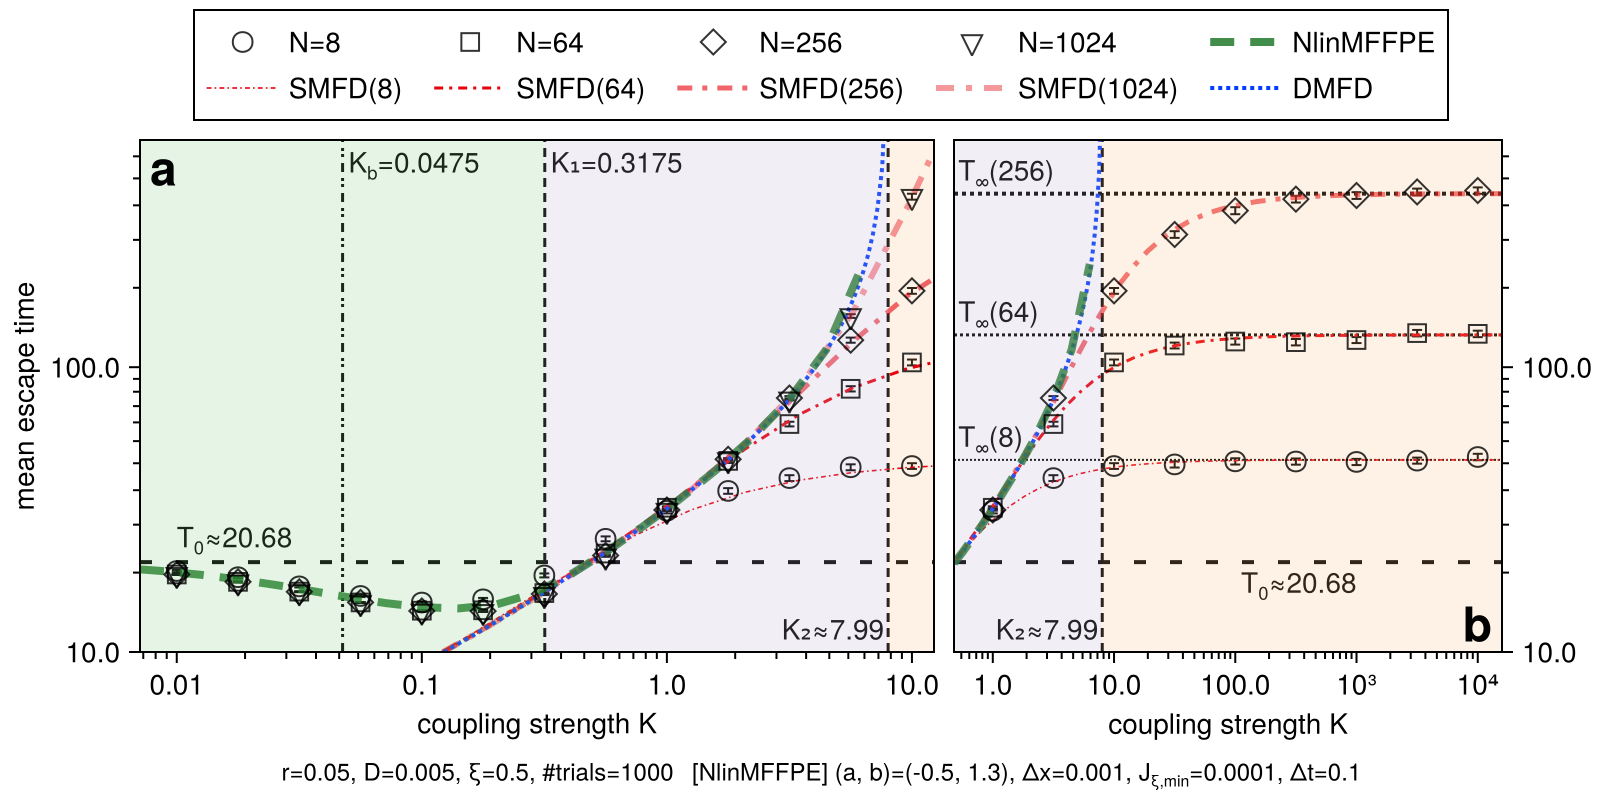

In [32]:
# generate the main figure
let savefig=true
    # SDE results
    (; fig, axes, dcol, delem) = get_met_axes(data)
    add_mfpt!(axes, dcol)
    add_Kc!(axes)  # K1 and K2
    delem2 = add_smfd!(axes, dcol)  # SMFD
    delem3 = add_dmfd!(axes)  # DMFD
    delem4 = add_fpe!(axes, fig)  # NlinMFFPE
    # put Legend
    delem = Dict(delem..., delem2..., delem3..., delem4...)
    lbl = [["N=$N" for N in Nall]; ["NlinMFFPE"]; ["SMFD($N)" for N in Nall]; ["DMFD"]]
    Legend(fig[0, 1:2], [delem[l] for l in lbl], lbl, 
        nbanks=5, #orientation=:horizontal, valign=:top,
        patchsize=(36, 20), tellheight=true, tellwidth=false, 
    )
    # annotate parameter values
    (; a, b, Δx, Jξmin, Δt) = fpe_param
    Label(fig[2, 1:2],
        rich(
            "r=$r, D=$D, ξ=$ξ, #trials=$(data.numsample) \t",
            "[NlinMFFPE] (a, b)=($a, $b), Δx=$Δx, J", 
            subscript("ξ,min"), 
            "=$Jξmin, Δt=$Δt"
        ),
        tellwidth=false, fontsize=12,
    )
    # adjust layout
    rowgap!(fig.layout, 10)
    # display
    display(fig)
    # save if necessary
    if savefig save("output/fig-met-vs-K.pdf", fig) end
end;